In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! tar -xvf /content/drive/MyDrive/project_2/MSD/Task04_Hippocampus.tar

./._Task04_Hippocampus
Task04_Hippocampus/
Task04_Hippocampus/._.DS_Store
Task04_Hippocampus/.DS_Store
Task04_Hippocampus/._labelsTr
Task04_Hippocampus/labelsTr/
Task04_Hippocampus/._imagesTr
Task04_Hippocampus/imagesTr/
Task04_Hippocampus/._imagesTs
Task04_Hippocampus/imagesTs/
Task04_Hippocampus/._dataset.json
Task04_Hippocampus/dataset.json
Task04_Hippocampus/imagesTs/hippocampus_267.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_379.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_208.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_275.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_131.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_140.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_076.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_115.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_168.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_119.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_021.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_121.nii.gz
Task04_Hippocampus/imagesTs/hippocampus_38

In [ ]:
!pip -q install nibabel imageio

In [ ]:
import os
from glob import glob

img_paths = sorted(glob("/content/Task04_Hippocampus/imagesTr/*.nii.gz"))
lab_paths = sorted(glob("/content/Task04_Hippocampus/labelsTr/*.nii.gz"))

assert len(img_paths) == len(lab_paths), (len(img_paths), len(lab_paths))

# 파일명 기준 매칭 체크(강력 추천)
def stem(p):
    return os.path.basename(p).replace(".nii.gz","")

img_stems = [stem(p) for p in img_paths]
lab_stems = [stem(p) for p in lab_paths]
assert img_stems == lab_stems, "imagesTr/labelsTr 파일명이 1:1로 정렬/매칭되지 않습니다."

print("cases:", len(img_paths))
print("example:", img_paths[0], lab_paths[0])

cases: 260
example: /content/Task04_Hippocampus/imagesTr/hippocampus_001.nii.gz /content/Task04_Hippocampus/labelsTr/hippocampus_001.nii.gz


In [ ]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset

class MSDHippocampus3DDataset(Dataset):
    def __init__(self, img_paths, lab_paths, patch_size=(96,96,96), samples_per_volume=4, binary=True):
        self.img_paths = img_paths
        self.lab_paths = lab_paths
        self.patch_size = np.array(patch_size)
        self.samples_per_volume = samples_per_volume
        self.binary = binary

    def __len__(self):
        # 한 볼륨에서 여러 patch를 뽑기 위해 length를 늘려줌
        return len(self.img_paths) * self.samples_per_volume

    def _load_case(self, idx):
        vidx = idx // self.samples_per_volume
        img = np.squeeze(nib.load(self.img_paths[vidx]).get_fdata()).astype(np.float32)
        lab = np.squeeze(nib.load(self.lab_paths[vidx]).get_fdata()).astype(np.int16)
        return img, lab

    # 로버스트 스케일링 같은 영역으로 처리하는 것도 알아보면 좋을 듯??
    def _zscore_nonzero(self, x):
        # 의료영상은 0이 배경인 경우가 많아서 nonzero만으로 z-score
        mask = x != 0
        if mask.sum() < 10:
            # 비정상 케이스 대비
            mean, std = x.mean(), x.std() + 1e-8
            return (x - mean) / std
        mean = x[mask].mean()
        std  = x[mask].std() + 1e-8
        x = (x - mean) / std
        return x

    def _pad_to_patch(self, img, lab):
        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        pad_h = max(0, ph - H)
        pad_w = max(0, pw - W)
        pad_d = max(0, pd - D)

        if pad_h or pad_w or pad_d:
            pad = (
                (pad_h//2, pad_h - pad_h//2),
                (pad_w//2, pad_w - pad_w//2),
                (pad_d//2, pad_d - pad_d//2),
            )
            img = np.pad(img, pad, mode="constant", constant_values=0)
            lab = np.pad(lab, pad, mode="constant", constant_values=0)

        return img, lab

    def _random_patch(self, img, lab):
        img, lab = self._pad_to_patch(img, lab)  # ✅ 먼저 패딩

        H, W, D = img.shape
        ph, pw, pd = map(int, self.patch_size)

        fg = np.argwhere(lab > 0)
        use_fg = (len(fg) > 0) and (np.random.rand() < 0.7)

        if use_fg:
            cx, cy, cz = fg[np.random.randint(len(fg))]  # (x,y,z)
        else:
            cx = np.random.randint(0, H)
            cy = np.random.randint(0, W)
            cz = np.random.randint(0, D)

        x1 = int(np.clip(cx - ph//2, 0, H - ph))
        y1 = int(np.clip(cy - pw//2, 0, W - pw))
        z1 = int(np.clip(cz - pd//2, 0, D - pd))

        img_p = img[x1:x1+ph, y1:y1+pw, z1:z1+pd]
        lab_p = lab[x1:x1+ph, y1:y1+pw, z1:z1+pd]

        # ✅ 안전 체크 (디버깅)
        assert img_p.shape == (ph, pw, pd), img_p.shape
        assert lab_p.shape == (ph, pw, pd), lab_p.shape

        return img_p, lab_p

    def __getitem__(self, idx):
        img, lab = self._load_case(idx)
        img = self._zscore_nonzero(img)

        img_p, lab_p = self._random_patch(img, lab)

        if self.binary:
            lab_p = (lab_p > 0).astype(np.int64)
        else:
            lab_p = lab_p.astype(np.int64)

        img_p = np.ascontiguousarray(img_p.astype(np.float32))
        lab_p = np.ascontiguousarray(lab_p)
        # ✅ torch.from_numpy 대신 torch.tensor로 강제 복사
        img_t = torch.tensor(img_p[None, ...], dtype=torch.float32)
        if self.binary :
            lab_t = torch.tensor(lab_p[None, ...], dtype=torch.int64)
        else :
            # ✅ 멀티클래스 라벨은 (H,W,D) long (CrossEntropyLoss 요구사항)
            lab_t = torch.tensor(lab_p, dtype=torch.long)

        return img_t, lab_t

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

BATCH = 8

train_imgs, val_imgs, train_labs, val_labs = train_test_split(
    img_paths, lab_paths, test_size=0.2, random_state=42
)

train_ds = MSDHippocampus3DDataset(train_imgs, train_labs, patch_size=(96,96,96), samples_per_volume=4, binary=False)
val_ds   = MSDHippocampus3DDataset(val_imgs,   val_labs,   patch_size=(96,96,96), samples_per_volume=2, binary=False)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

x, y = next(iter(train_loader))
print(x.shape, y.shape, x.dtype, y.unique())

torch.Size([8, 1, 96, 96, 96]) torch.Size([8, 96, 96, 96]) torch.float32 tensor([0, 1, 2])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Normalization helper
# -------------------------
def norm3d(num_features, norm="bn"):
    if norm == "bn":
        return nn.BatchNorm3d(num_features)
    elif norm == "in":
        return nn.InstanceNorm3d(num_features, affine=True)
    else:
        raise ValueError("norm must be 'bn' or 'in'")

# -------------------------
# ResNet3D blocks
# -------------------------
class BasicBlock3D(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, dilation=1, downsample=None, norm="bn"):
        super().__init__()
        self.conv1 = nn.Conv3d(inplanes, planes, kernel_size=3,
                               stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.bn1 = norm3d(planes, norm)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv3d(planes, planes, kernel_size=3,
                               stride=1, padding=dilation, dilation=dilation, bias=False)
        self.bn2 = norm3d(planes, norm)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.relu(out + identity)
        return out

class Bottleneck3D(nn.Module):
    expansion = 4
    def __init__(self, inplanes, planes, stride=1, dilation=1, downsample=None, norm="bn"):
        super().__init__()
        width = planes
        self.conv1 = nn.Conv3d(inplanes, width, kernel_size=1, bias=False)
        self.bn1 = norm3d(width, norm)

        self.conv2 = nn.Conv3d(width, width, kernel_size=3,
                               stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.bn2 = norm3d(width, norm)

        self.conv3 = nn.Conv3d(width, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = norm3d(planes * self.expansion, norm)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.relu(out + identity)
        return out

# -------------------------
# ResNet3D backbone (outputs low-level + high-level)
# Output stride configurable: 8 or 16
# -------------------------
class ResNet3D(nn.Module):
    def __init__(self, block, layers, in_channels=1, base=64, output_stride=16, norm="bn"):
        super().__init__()
        assert output_stride in (8, 16), "output_stride must be 8 or 16"

        self.inplanes = base
        self.norm = norm

        # stem
        self.conv1 = nn.Conv3d(in_channels, base, kernel_size=7, stride=2, padding=3, bias=False)  # /2
        self.bn1 = norm3d(base, norm)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)  # /4

        # strides/dilations to achieve output_stride
        # Standard: layer2 stride=2, layer3 stride=2, layer4 stride=2 -> /32
        # We want /16 or /8 at the end by replacing strides with dilation.
        if output_stride == 16:
            s2, s3, s4 = 2, 2, 1
            d2, d3, d4 = 1, 1, 2
        else:  # output_stride == 8
            s2, s3, s4 = 2, 1, 1
            d2, d3, d4 = 1, 2, 4

        # layer1 keeps /4, good for low-level (DeepLabV3+ uses early features)
        self.layer1 = self._make_layer(block, base, layers[0], stride=1, dilation=1)         # /4
        self.layer2 = self._make_layer(block, base*2, layers[1], stride=s2, dilation=d2)     # /8 or /8
        self.layer3 = self._make_layer(block, base*4, layers[2], stride=s3, dilation=d3)     # /16 or /8
        self.layer4 = self._make_layer(block, base*8, layers[3], stride=s4, dilation=d4)     # /16 or /8 (final high-level)

        self.out_channels = base*8 * block.expansion
        self.low_channels = base * block.expansion  # layer1 output channels

    def _make_layer(self, block, planes, blocks, stride, dilation):
        downsample = None
        outplanes = planes * block.expansion
        if stride != 1 or self.inplanes != outplanes:
            downsample = nn.Sequential(
                nn.Conv3d(self.inplanes, outplanes, kernel_size=1, stride=stride, bias=False),
                norm3d(outplanes, self.norm)
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride=stride, dilation=dilation, downsample=downsample, norm=self.norm))
        self.inplanes = outplanes
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, stride=1, dilation=dilation, downsample=None, norm=self.norm))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x: (B,1,H,W,D)
        x = self.relu(self.bn1(self.conv1(x)))   # /2
        x = self.maxpool(x)                      # /4
        low = self.layer1(x)                     # /4  (low-level)
        x = self.layer2(low)
        x = self.layer3(x)
        high = self.layer4(x)                    # /16 or /8 (high-level)
        return low, high

def resnet3d18(in_channels=1, base=64, output_stride=16, norm="bn"):
    return ResNet3D(BasicBlock3D, [2,2,2,2], in_channels, base, output_stride, norm)

def resnet3d34(in_channels=1, base=64, output_stride=16, norm="bn"):
    return ResNet3D(BasicBlock3D, [3,4,6,3], in_channels, base, output_stride, norm)

def resnet3d50(in_channels=1, base=64, output_stride=16, norm="bn"):
    return ResNet3D(Bottleneck3D, [3,4,6,3], in_channels, base, output_stride, norm)

def resnet3d101(in_channels=1, base=64, output_stride=16, norm="bn"):
    return ResNet3D(Bottleneck3D, [3,4,23,3], in_channels, base, output_stride, norm)

# -------------------------
# ASPP 3D
# -------------------------
class ASPP3D(nn.Module):
    def __init__(self, in_ch, out_ch, rates=(1, 6, 12, 18), norm="bn"):
        super().__init__()
        self.norm = norm

        self.b0 = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False),
            norm3d(out_ch, norm),
            nn.ReLU(inplace=True)
        )

        self.branches = nn.ModuleList()
        for r in rates[1:]:
            self.branches.append(nn.Sequential(
                nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=r, dilation=r, bias=False),
                norm3d(out_ch, norm),
                nn.ReLU(inplace=True)
            ))

        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False),
            norm3d(out_ch, norm),
            nn.ReLU(inplace=True)
        )

        n = 1 + len(self.branches) + 1
        self.proj = nn.Sequential(
            nn.Conv3d(out_ch * n, out_ch, kernel_size=1, bias=False),
            norm3d(out_ch, norm),
            nn.ReLU(inplace=True),
            nn.Dropout3d(0.1)
        )

    def forward(self, x):
        feats = [self.b0(x)]
        for br in self.branches:
            feats.append(br(x))
        gp = self.pool(x)
        gp = F.interpolate(gp, size=x.shape[2:], mode="trilinear", align_corners=False)
        feats.append(gp)
        return self.proj(torch.cat(feats, dim=1))

# -------------------------
# DeepLabV3+ 3D
# -------------------------
class DeepLabV3Plus3D(nn.Module):
    def __init__(self, in_channels=1, num_classes=3,
                 backbone="resnet3d50", output_stride=16,
                 aspp_out=256, low_out=48, norm="bn"):
        super().__init__()
        # backbone
        if backbone == "resnet3d18":
            self.backbone = resnet3d18(in_channels, base=64, output_stride=output_stride, norm=norm)
        elif backbone == "resnet3d34":
            self.backbone = resnet3d34(in_channels, base=64, output_stride=output_stride, norm=norm)
        elif backbone == "resnet3d50":
            self.backbone = resnet3d50(in_channels, base=64, output_stride=output_stride, norm=norm)
        elif backbone == "resnet3d101":
            self.backbone = resnet3d101(in_channels, base=64, output_stride=output_stride, norm=norm)
        else:
            raise ValueError("backbone must be one of: resnet3d18/34/50/101")

        # ASPP rates: OS=16 -> (1,6,12,18), OS=8 -> (1,12,24,36) (2D 관용을 3D에 그대로 적용)
        rates = (1, 6, 12, 18) if output_stride == 16 else (1, 12, 24, 36)
        self.aspp = ASPP3D(self.backbone.out_channels, aspp_out, rates=rates, norm=norm)

        # low-level projection
        self.low_proj = nn.Sequential(
            nn.Conv3d(self.backbone.low_channels, low_out, kernel_size=1, bias=False),
            norm3d(low_out, norm),
            nn.ReLU(inplace=True)
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.Conv3d(aspp_out + low_out, 256, kernel_size=3, padding=1, bias=False),
            norm3d(256, norm),
            nn.ReLU(inplace=True),
            nn.Conv3d(256, 256, kernel_size=3, padding=1, bias=False),
            norm3d(256, norm),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Conv3d(256, num_classes, kernel_size=1)

    def forward(self, x):
        # x: (B,1,H,W,D)
        low, high = self.backbone(x)  # low: /4, high: /OS

        high = self.aspp(high)
        high_up = F.interpolate(high, size=low.shape[2:], mode="trilinear", align_corners=False)

        low = self.low_proj(low)
        fused = torch.cat([high_up, low], dim=1)

        out = self.decoder(fused)
        out = self.classifier(out)

        out = F.interpolate(out, size=x.shape[2:], mode="trilinear", align_corners=False)
        return out

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: (B,1,H,W,D), targets: (B,1,H,W,D) with {0,1}
        probs = torch.sigmoid(logits)
        targets = targets.float()
        dims = (2,3,4)

        intersection = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

@torch.no_grad()
def dice_score(logits, targets, thr=0.5, smooth=1.0):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    targets = targets.float()
    dims = (2,3,4)

    intersection = (preds * targets).sum(dims)
    union = preds.sum(dims) + targets.sum(dims)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.mean().item()

class SoftDiceLossMulti(nn.Module):
    def __init__(self, num_classes, smooth=1.0, ignore_index=None):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)  # (B,C,H,W,D)
        targets_oh = F.one_hot(targets, num_classes=self.num_classes).permute(0,4,1,2,3).float()

        dims = (2,3,4)
        inter = (probs * targets_oh).sum(dims)
        union = probs.sum(dims) + targets_oh.sum(dims)
        dice = (2*inter + self.smooth) / (union + self.smooth)  # (B,C)

        if self.ignore_index is not None:
            keep = [c for c in range(self.num_classes) if c != self.ignore_index]
            dice = dice[:, keep]

        return 1 - dice.mean()

@torch.no_grad()
def dice_score_mc(logits, targets, num_classes=2, ignore_index=0, smooth=1.0):
    pred = logits.argmax(dim=1)  # (B,H,W,D)
    dices = []
    for c in range(num_classes):
        if c == ignore_index:
            continue
        p = (pred == c).float()
        t = (targets == c).float()
        inter = (p*t).sum()
        union = p.sum() + t.sum()
        dices.append(((2*inter + smooth)/(union + smooth)).item())
    return float(sum(dices)/max(len(dices),1))

In [ ]:
from tqdm.notebook import tqdm
import torch

NUM_CLASSES = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = DeepLabV3Plus3D(
    in_channels=1,
    num_classes=NUM_CLASSES,
    backbone="resnet3d50",
    output_stride=16,   # 16이 보통 안정적, 더 디테일 원하면 8
    aspp_out=256,
    norm="bn"
).to(device)

ce   = nn.CrossEntropyLoss()                         # ✅ 멀티클래스용
dice = SoftDiceLossMulti(NUM_CLASSES, ignore_index=0) # 배경(0) dice 제외 추천

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def run_one_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_dice = 0.0
    n = 0

    for x, y in tqdm(loader):
        x = x.to(device, non_blocking=True)  # (B,1,H,W,D)

        y = y.to(device, non_blocking=True)  # (B,H,W,D) long expected
        if y.ndim == 5:                      # 혹시 (B,1,H,W,D)로 들어오면
            y = y.squeeze(1)
        y = y.long()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x)                # (B,2,H,W,D)
            loss_ce = ce(logits, y)
            loss_dice = dice(logits, y)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_score_mc(logits.detach(), y, num_classes=NUM_CLASSES, ignore_index=0) * bs
        n += bs

    return total_loss / n, total_dice / n

best_val = -1.0
save_path = "/content/drive/MyDrive/project_2/best_DeepLabV3Plus3D.pth"

epochs = 30
for epoch in tqdm(range(1, epochs + 1)):
    tr_loss, tr_dice = run_one_epoch(train_loader, train=True)
    va_loss, va_dice = run_one_epoch(val_loader, train=False)

    print(f"[{epoch:02d}/{epochs}] "
          f"train loss={tr_loss:.4f}, dice={tr_dice:.4f} | "
          f"val loss={va_loss:.4f}, dice={va_dice:.4f}")

    if va_dice > best_val:
        best_val = va_dice
        torch.save(
            {"model": model.state_dict(),
             "optimizer": optimizer.state_dict(),
             "epoch": epoch,
             "val_dice": best_val},
            save_path
        )
        print(f"  ✅ saved best -> {save_path} (val_dice={best_val:.4f})")

device: cuda


/tmp/ipython-input-4075407285.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipython-input-4075407285.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

  0%|          | 0/13 [00:00<?, ?it/s]

[29/30] train loss=0.0331, dice=0.9409 | val loss=0.0860, dice=0.8419


  0%|          | 0/104 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

[30/30] train loss=0.0351, dice=0.9369 | val loss=0.0854, dice=0.8431


In [ ]:
import torch
import numpy as np
import nibabel as nib
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("/content/drive/MyDrive/project_2/best_DeepLabV3Plus3D.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

print("Loaded model from epoch:", ckpt["epoch"])

Loaded model from epoch: 19


In [ ]:
@torch.no_grad()
def sliding_window_predict_3d(
    model,
    volume_np,
    patch_size=(96,96,96),
    overlap=0.5,
    device="cuda"
):
    """
    volume_np: (H,W,D)
    return: prob_map (H,W,D) in [0,1]
    """
    model.eval()

    H, W, D = volume_np.shape
    ph, pw, pd = patch_size

    sh = max(1, int(ph * (1 - overlap)))
    sw = max(1, int(pw * (1 - overlap)))
    sd = max(1, int(pd * (1 - overlap)))

    prob_sum = np.zeros((H, W, D), dtype=np.float32)
    count    = np.zeros((H, W, D), dtype=np.float32)

    xs = list(range(0, max(1, H - ph + 1), sh))
    ys = list(range(0, max(1, W - pw + 1), sw))
    zs = list(range(0, max(1, D - pd + 1), sd))
    if xs[-1] != H - ph: xs.append(H - ph)
    if ys[-1] != W - pw: ys.append(W - pw)
    if zs[-1] != D - pd: zs.append(D - pd)

    for x1 in xs:
        for y1 in ys:
            for z1 in zs:
                patch = volume_np[x1:x1+ph, y1:y1+pw, z1:z1+pd]
                x_t = torch.tensor(
                    patch[None, None, ...],
                    dtype=torch.float32,
                    device=device
                )

                with torch.cuda.amp.autocast(enabled=(device=="cuda")):
                    logits = model(x_t)
                    probs = torch.sigmoid(logits)[0,0].cpu().numpy()

                prob_sum[x1:x1+ph, y1:y1+pw, z1:z1+pd] += probs
                count[x1:x1+ph, y1:y1+pw, z1:z1+pd] += 1.0

    return prob_sum / np.maximum(count, 1e-8)

In [ ]:
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F

def zscore_nonzero_np(x):
    x = x.astype(np.float32)
    m = x != 0
    if m.sum() < 10:
        return (x - x.mean()) / (x.std() + 1e-8)
    mean = x[m].mean()
    std  = x[m].std() + 1e-8
    return (x - mean) / std

@torch.no_grad()
def sliding_window_predict_auto(model, volume_np, patch_size=(96,96,96), overlap=0.5, device=None):
    """
    return:
      pred: (H,W,D) uint8 class map (binary면 0/1, multi면 0..C-1)
      prob_or_none: binary면 (H,W,D) prob map(float32), multi면 None(필요시 확장 가능)
    """
    model.eval()
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # out_channels 추정
    C = None
    if hasattr(model, "out") and hasattr(model.out, "out_channels"):
        C = model.out.out_channels
    else:
        # fallback: 한 번 forward 해서 채널 수 확인
        dummy = torch.zeros(1,1,*patch_size, device=device)
        C = model(dummy).shape[1]

    H, W, D = volume_np.shape
    ph, pw, pd = patch_size

    sh = max(1, int(ph * (1 - overlap)))
    sw = max(1, int(pw * (1 - overlap)))
    sd = max(1, int(pd * (1 - overlap)))

    # 시작 인덱스들 (끝까지 덮도록)
    xs = list(range(0, max(1, H - ph + 1), sh))
    ys = list(range(0, max(1, W - pw + 1), sw))
    zs = list(range(0, max(1, D - pd + 1), sd))
    if xs[-1] != H - ph: xs.append(H - ph)
    if ys[-1] != W - pw: ys.append(W - pw)
    if zs[-1] != D - pd: zs.append(D - pd)

    # 누적 버퍼
    if C == 1:
        prob_sum = np.zeros((H, W, D), dtype=np.float32)
    else:
        prob_sum = np.zeros((C, H, W, D), dtype=np.float32)
    count = np.zeros((H, W, D), dtype=np.float32)

    for x1 in xs:
        for y1 in ys:
            for z1 in zs:
                patch = volume_np[x1:x1+ph, y1:y1+pw, z1:z1+pd]
                x_t = torch.tensor(patch[None, None, ...], dtype=torch.float32, device=device)

                with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
                    logits = model(x_t)  # (1,C,ph,pw,pd)

                    if C == 1:
                        probs = torch.sigmoid(logits)[0,0].float().cpu().numpy()  # (ph,pw,pd)
                        prob_sum[x1:x1+ph, y1:y1+pw, z1:z1+pd] += probs
                    else:
                        probs = F.softmax(logits, dim=1)[0].float().cpu().numpy()  # (C,ph,pw,pd)
                        prob_sum[:, x1:x1+ph, y1:y1+pw, z1:z1+pd] += probs

                count[x1:x1+ph, y1:y1+pw, z1:z1+pd] += 1.0

    if C == 1:
        prob_map = prob_sum / np.maximum(count, 1e-8)
        pred = (prob_map > 0.5).astype(np.uint8)
        return pred, prob_map
    else:
        prob_map = prob_sum / np.maximum(count[None, ...], 1e-8)
        pred = prob_map.argmax(axis=0).astype(np.uint8)
        return pred, None

In [ ]:
def best_slice_index_from_gt(gt, axis=2):
    # gt: (H,W,D) 값>0인 면적이 최대인 slice index
    if axis == 0:
        areas = (gt > 0).sum(axis=(1,2))
    elif axis == 1:
        areas = (gt > 0).sum(axis=(0,2))
    else:
        areas = (gt > 0).sum(axis=(0,1))
    return int(np.argmax(areas))

In [ ]:
import matplotlib.pyplot as plt

def visualize_case(img_np, gt_np, pred_np, axis=2, slice_idx=None, title_prefix=""):
    """
    img_np: (H,W,D)
    gt_np:  (H,W,D) 0/1 or 0/1/2...
    pred_np:(H,W,D) 0/1 or 0/1/2...
    """
    if slice_idx is None:
        slice_idx = best_slice_index_from_gt(gt_np, axis=axis)

    if axis == 0:
        img2 = img_np[slice_idx, :, :]
        gt2  = gt_np[slice_idx, :, :]
        pr2  = pred_np[slice_idx, :, :]
    elif axis == 1:
        img2 = img_np[:, slice_idx, :]
        gt2  = gt_np[:, slice_idx, :]
        pr2  = pred_np[:, slice_idx, :]
    else:
        img2 = img_np[:, :, slice_idx]
        gt2  = gt_np[:, :, slice_idx]
        pr2  = pred_np[:, :, slice_idx]

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.title(f"{title_prefix}Image (axis={axis}, idx={slice_idx})")
    plt.imshow(img2, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("GT (Green) vs Pred (Red)")
    plt.imshow(img2, cmap="gray")
    # GT: green
    plt.imshow((gt2 > 0).astype(np.float32), alpha=0.35, cmap="Greens")
    # Pred: red
    plt.imshow((pr2 > 0).astype(np.float32), alpha=0.35, cmap="Reds")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Errors: FP=Red, FN=Blue")
    fp = ((pr2 > 0) & (gt2 == 0)).astype(np.float32)
    fn = ((pr2 == 0) & (gt2 > 0)).astype(np.float32)
    plt.imshow(img2, cmap="gray")
    plt.imshow(fp, alpha=0.45, cmap="Reds")
    plt.imshow(fn, alpha=0.45, cmap="Blues")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-627015666.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


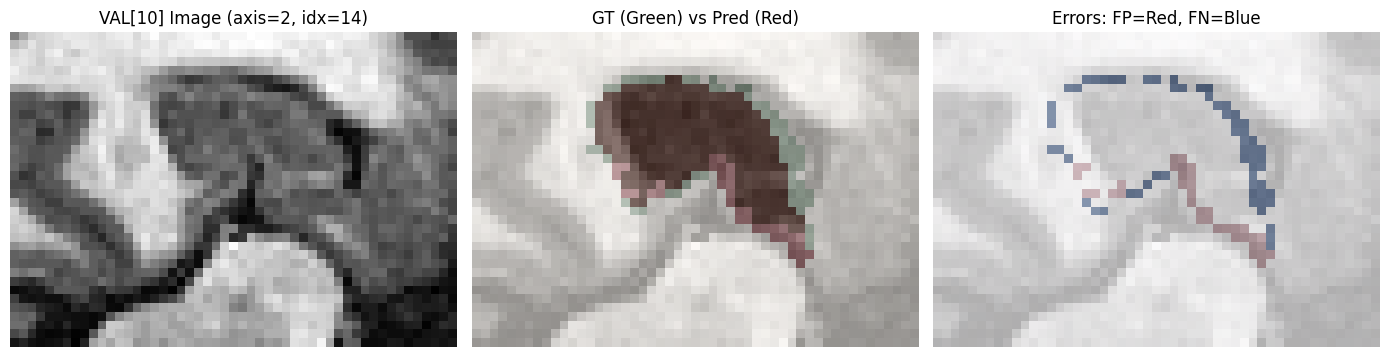

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()  # 이미 로드되어 있다고 가정

case_idx = 20  # 보고 싶은 val index

img_nii = nib.load(val_imgs[case_idx])
lab_nii = nib.load(val_labs[case_idx])

img = np.squeeze(img_nii.get_fdata()).astype(np.float32)
gt  = np.squeeze(lab_nii.get_fdata()).astype(np.int16)

img_norm = zscore_nonzero_np(img)

pred, prob = sliding_window_predict_auto(
    model,
    img_norm,
    patch_size=(96,96,96),
    overlap=0.5,
    device=device
)

# GT가 0/1/2면 그대로 비교 가능, binary면 (gt>0)으로 통일하고 싶으면 아래 한 줄:
# gt = (gt > 0).astype(np.uint8)

visualize_case(img, gt, pred, axis=2, slice_idx=None, title_prefix=f"VAL[{case_idx}] ")